# 1. Entorno

In [47]:
%pip install pandas matplotlib numpy seaborn scikit-learn nltk wordcloud tensorflow

Note: you may need to restart the kernel to use updated packages.


In [48]:
import pandas as pd

csv_path = "news_dataset.csv"
df = pd.read_csv(csv_path, sep=',')

print("Tamaño del dataset:", df.shape)
print("Columnas:", list(df.columns))
print("Valores nulos por columna:")
print(df.isnull().sum())

display(df.head())
print()
print("Información del dataset:")
df.info()
print()
print("Estadísticas descriptivas:")
display(df.describe(include='all'))


Tamaño del dataset: (120000, 3)
Columnas: ['Class Index', 'Title', 'Description']
Valores nulos por columna:
Class Index    0
Title          0
Description    0
dtype: int64


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.7 MB

Estadísticas descriptivas:


,Class Index,Title,Description
count,120000.000000,120000,120000
unique,NaN,114350,118723
top,NaN,Today's schedule,"With the economy slowly turning up, upgrading ..."
freq,NaN,39,15
mean,2.500000,NaN,NaN
std,1.118039,NaN,NaN
min,1.000000,NaN,NaN
25%,1.750000,NaN,NaN
50%,2.500000,NaN,NaN
75%,3.250000,NaN,NaN


In [49]:
TARGET_COL = "Class Index"
TEXT_COLS = ["Title", "Description"]

df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


## 1.1 Comprobación de nulls

In [50]:
df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

Como podemos observar ninguno de las columnas posee nulls por lo que técnicas de añadir o quitar datos no son necesarias.

## 1.2 Desbalanceo de datos

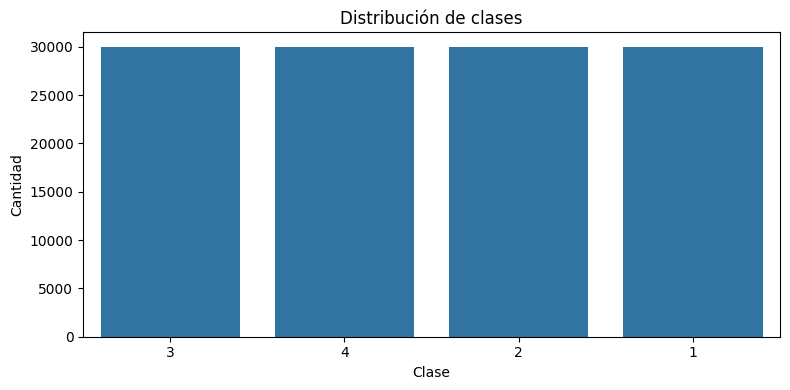

Class Index
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Class Index", order=df["Class Index"].value_counts().index)
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

df["Class Index"].value_counts(normalize=True).sort_index()



Podemos observar que los distitnos corpus que tenemos `1`, `2`, `3` y `4` presentan la misma cantidad de datos por lo que tampoco hay riesgo de desbalance.

## 1.3 Para analizar longitud del texto por clase:

In [52]:
df["title_length"] = df["Title"].str.len()
df["description_length"] = df["Description"].str.len()
df["text_length"] = df["Description"].str.len()
df["word_count"] = df["Description"].str.split().str.len()

df[["title_length", "description_length", "text_length", "word_count"]].describe()


,title_length,description_length,text_length,word_count
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,42.071508,193.388517,193.388517,31.060508
std,13.569405,64.472066,64.472066,9.760460
min,6.000000,6.000000,6.000000,1.000000
25%,33.000000,155.000000,155.000000,25.000000
50%,41.000000,188.000000,188.000000,30.000000
75%,49.000000,219.000000,219.000000,36.000000
max,115.000000,985.000000,985.000000,173.000000


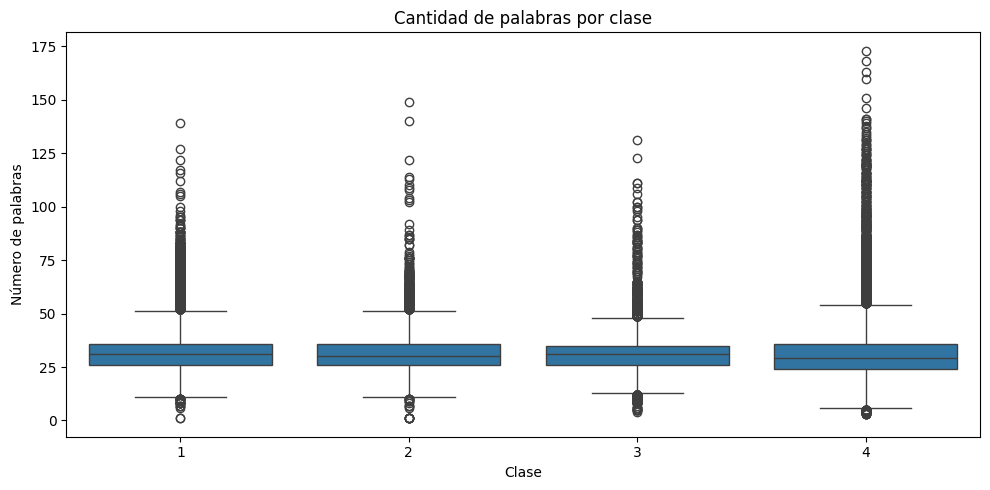

In [53]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Class Index", y="word_count")
plt.title("Cantidad de palabras por clase")
plt.xlabel("Clase")
plt.ylabel("Número de palabras")
plt.tight_layout()
plt.show()

## 1.4 Preprocesamiento del texto para Skip-Gram:

In [54]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["Description"].apply(clean_text)
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

df[["Description", "clean_text", "tokens"]].head()


,Description,clean_text,tokens
0,"Reuters - Short-sellers, Wall Street's dwindli...",reuters short sellers wall street s dwindling ...,"[reuters, short, sellers, wall, street, s, dwi..."
1,Reuters - Private investment firm Carlyle Grou...,reuters private investment firm carlyle group ...,"[reuters, private, investment, firm, carlyle, ..."
2,Reuters - Soaring crude prices plus worries\ab...,reuters soaring crude prices plus worries abou...,"[reuters, soaring, crude, prices, plus, worrie..."
3,Reuters - Authorities have halted oil export\f...,reuters authorities have halted oil export flo...,"[reuters, authorities, have, halted, oil, expo..."
4,"AFP - Tearaway world oil prices, toppling reco...",afp tearaway world oil prices toppling records...,"[afp, tearaway, world, oil, prices, toppling, ..."


In [55]:
skipgram_sentences = df["tokens"].tolist()

skipgram_sentences[:2]


[['reuters',
  'short',
  'sellers',
  'wall',
  'street',
  's',
  'dwindling',
  'band',
  'of',
  'ultra',
  'cynics',
  'are',
  'seeing',
  'green',
  'again'],
 ['reuters',
  'private',
  'investment',
  'firm',
  'carlyle',
  'group',
  'which',
  'has',
  'a',
  'reputation',
  'for',
  'making',
  'well',
  'timed',
  'and',
  'occasionally',
  'controversial',
  'plays',
  'in',
  'the',
  'defense',
  'industry',
  'has',
  'quietly',
  'placed',
  'its',
  'bets',
  'on',
  'another',
  'part',
  'of',
  'the',
  'market']]

In [56]:
from gensim.models import Word2Vec

skipgram_model = Word2Vec(
    sentences=skipgram_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    epochs=10
)

print("Tamaño del vocabulario:", len(skipgram_model.wv))


Tamaño del vocabulario: 39585


In [57]:
word = "market"

if word in skipgram_model.wv:
    display(skipgram_model.wv.most_similar(word, topn=10))
else:
    print("La palabra no está en el vocabulario.")


[('sector', 0.6903860569000244),
 ('fundamentals', 0.6396070718765259),
 ('sharemarket', 0.6395574808120728),
 ('slackening', 0.6297253966331482),
 ('toehold', 0.6265332698822021),
 ('indices', 0.6248734593391418),
 ('ringtone', 0.6231670379638672),
 ('cutthroat', 0.6171799898147583),
 ('capitalization', 0.613551676273346),
 ('inroads', 0.6058790683746338)]

In [58]:
df[["Class Index", "Title", "Description", "clean_text", "tokens"]].to_csv(
    "dataset_texto_preprocesado.csv",
    index=False
)

skipgram_model.save("skipgram_word2vec.model")


# 2. Implementación

## 2.1 Separar datos

In [59]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Class Index"]
)

train_sentences = train_df["tokens"].tolist()
test_sentences = test_df["tokens"].tolist()

print("Textos de entrenamiento:", len(train_sentences))
print("Textos de prueba:", len(test_sentences))


Textos de entrenamiento: 96000
Textos de prueba: 24000


### Comprobamos que no hemos creado desbalance en la separación

In [60]:
print("Distribución original:")
display(df["Class Index"].value_counts().sort_index())

print("Distribución entrenamiento:")
display(train_df["Class Index"].value_counts().sort_index())

print("Distribución prueba:")
display(test_df["Class Index"].value_counts().sort_index())


Distribución original:


Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64

Distribución entrenamiento:


Class Index
1    24000
2    24000
3    24000
4    24000
Name: count, dtype: int64

Distribución prueba:


Class Index
1    6000
2    6000
3    6000
4    6000
Name: count, dtype: int64

Como podemos observar no ha sido el caso

## 2.2  Generar diccionario desde entrenamiento

In [61]:
from collections import Counter

MIN_FREQ = 2

word_counter = Counter()

for sentence in train_sentences:
    word_counter.update(sentence)

vocab_words = [
    word for word, freq in word_counter.items()
    if freq >= MIN_FREQ
]

word_to_index = {
    word: idx + 1
    for idx, word in enumerate(vocab_words)
}

index_to_word = {
    idx: word
    for word, idx in word_to_index.items()
}

vocab_size = len(word_to_index) + 1

print("Tamaño del vocabulario:", vocab_size)
print("Primeras palabras:", list(word_to_index.items())[:10])


Tamaño del vocabulario: 36371
Primeras palabras: [('tokyo', 1), ('reuters', 2), ('belgian', 3), ('kim', 4), ('clijsters', 5), ('is', 6), ('unsure', 7), ('about', 8), ('the', 9), ('exact', 10)]


## 2.4 Convertir textos a secuencias numéricas

In [62]:
def sentence_to_indices(sentence, word_to_index):
    return [
        word_to_index[word]
        for word in sentence
        if word in word_to_index
    ]

train_sequences = [
    sentence_to_indices(sentence, word_to_index)
    for sentence in train_sentences
]

train_sequences = [
    sequence for sequence in train_sequences
    if len(sequence) > 1
]

print("Secuencias válidas:", len(train_sequences))
print(train_sequences[0][:20])


Secuencias válidas: 95992
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 9, 13, 14, 15, 16, 17, 18, 19]


## 2.5 Generar pares positivos con ventanas 2, 3 y 4

In [63]:
def generate_positive_pairs(sequences, window_size):
    pairs = []

    for sequence in sequences:
        sequence_length = len(sequence)

        for center_position, center_word in enumerate(sequence):
            start = max(0, center_position - window_size)
            end = min(sequence_length, center_position + window_size + 1)

            for context_position in range(start, end):
                if context_position != center_position:
                    context_word = sequence[context_position]
                    pairs.append((center_word, context_word))

    return pairs

positive_pairs_by_window = {}

for window_size in [2, 3, 4]:
    pairs = generate_positive_pairs(train_sequences, window_size)
    positive_pairs_by_window[window_size] = pairs
    print(f"Ventana {window_size}: {len(pairs)} pares positivos")


Ventana 2: 11824596 pares positivos
Ventana 3: 17448920 pares positivos
Ventana 4: 22881264 pares positivos


## 2.6 Generar pares negativos y etiquetas

In [64]:
import numpy as np

def generate_training_pairs(positive_pairs, vocab_size, negative_ratio=1, random_state=42):
    rng = np.random.default_rng(random_state)

    positive_pairs = np.array(positive_pairs, dtype=np.int32)
    num_positive = len(positive_pairs)
    num_negative = num_positive * negative_ratio

    negative_centers = positive_pairs[
        rng.integers(0, num_positive, size=num_negative),
        0
    ]

    negative_contexts = rng.integers(
        1,
        vocab_size,
        size=num_negative,
        dtype=np.int32
    )

    negative_pairs = np.column_stack([
        negative_centers,
        negative_contexts
    ])

    X = np.vstack([
        positive_pairs,
        negative_pairs
    ])

    y = np.concatenate([
        np.ones(num_positive),
        np.zeros(num_negative)
    ])

    shuffle_indices = rng.permutation(len(X))

    X = X[shuffle_indices]
    y = y[shuffle_indices]

    center_words = X[:, 0]
    context_words = X[:, 1]

    return center_words, context_words, y


## 2.7 Crear red neuronal Skip-Gram

In [65]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import regularizers

def build_skipgram_model(vocab_size, embedding_dim):
    center_input = layers.Input(shape=(1,), name="center_word")
    context_input = layers.Input(shape=(1,), name="context_word")

    embedding_layer = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=regularizers.l2(1e-6),
        name="word_embedding"
    )

    center_embedding = embedding_layer(center_input)
    context_embedding = embedding_layer(context_input)

    dot_product = layers.Dot(axes=-1)([
        center_embedding,
        context_embedding
    ])

    dot_product = layers.Reshape((1,))(dot_product)

    output = layers.Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=regularizers.l2(1e-6)
    )(dot_product)

    model = Model(
        inputs=[center_input, context_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model



## 2.8 Definir experimentos

In [ ]:
embedding_sizes = [100, 200, 312]
window_sizes = [2, 3, 4]

EXPERIMENTS = [
    (window_size, embedding_dim)
    for window_size in window_sizes
    for embedding_dim in embedding_sizes
]

print("Número de modelos:", len(EXPERIMENTS))
print(EXPERIMENTS)


Número de modelos: 9
[(2, 100), (2, 200), (2, 312), (3, 100), (3, 200), (3, 312), (4, 100), (4, 200), (4, 312)]


## 2.9 Monitoreo

In [67]:
class_monitor = pd.DataFrame({
    "original_count": df["Class Index"].value_counts().sort_index(),
    "train_count": train_df["Class Index"].value_counts().sort_index(),
    "test_count": test_df["Class Index"].value_counts().sort_index(),
    "original_%": df["Class Index"].value_counts(normalize=True).sort_index() * 100,
    "train_%": train_df["Class Index"].value_counts(normalize=True).sort_index() * 100,
    "test_%": test_df["Class Index"].value_counts(normalize=True).sort_index() * 100
})

class_monitor


,original_count,train_count,test_count,original_%,train_%,test_%
Class Index,,,,,,
1,30000,24000,6000,25.0,25.0,25.0
2,30000,24000,6000,25.0,25.0,25.0
3,30000,24000,6000,25.0,25.0,25.0
4,30000,24000,6000,25.0,25.0,25.0


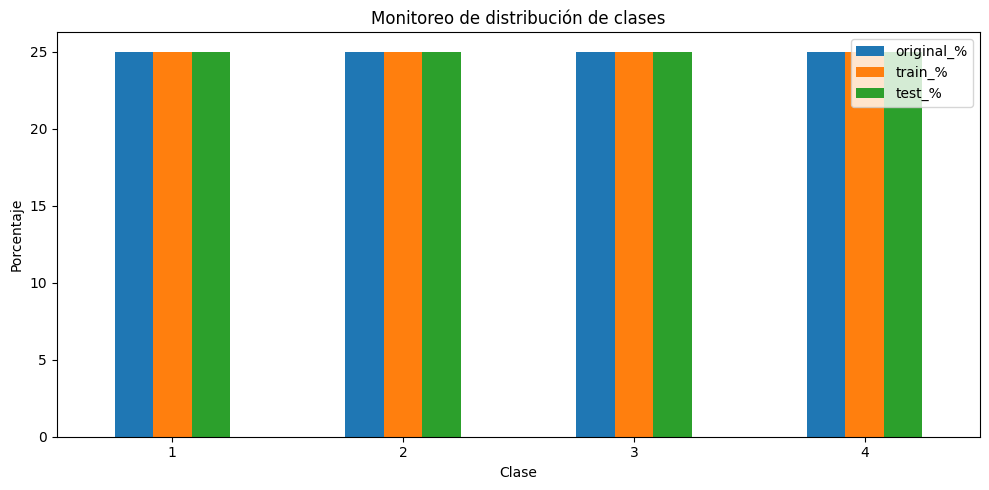

In [68]:
class_monitor[["original_%", "train_%", "test_%"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Monitoreo de distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [69]:
vocab_monitor = pd.DataFrame(
    word_counter.most_common(30),
    columns=["word", "frequency"]
)

vocab_monitor.head()


,word,frequency
0,the,159321
1,a,86692
2,to,77455
3,of,71897
4,in,63002


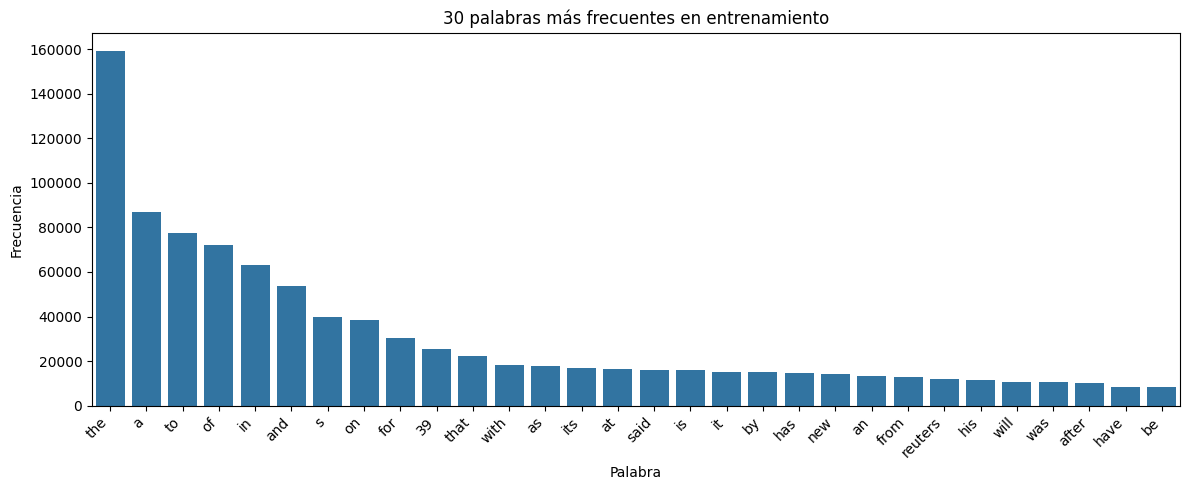

In [70]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=vocab_monitor,
    x="word",
    y="frequency"
)

plt.title("30 palabras más frecuentes en entrenamiento")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [71]:
vocab_stats = {
    "total_unique_words_before_filter": len(word_counter),
    "total_words_after_min_freq": len(word_to_index),
    "vocab_size_with_padding": vocab_size,
    "min_freq": MIN_FREQ
}

vocab_stats


{'total_unique_words_before_filter': 56036,
 'total_words_after_min_freq': 36370,
 'vocab_size_with_padding': 36371,
 'min_freq': 2}

In [72]:
sequence_lengths = [len(sequence) for sequence in train_sequences]

sequence_monitor = pd.Series(sequence_lengths).describe()

sequence_monitor


count    95992.000000
mean        32.295785
std         11.069040
min          2.000000
25%         26.000000
50%         31.000000
75%         37.000000
max        174.000000
dtype: float64

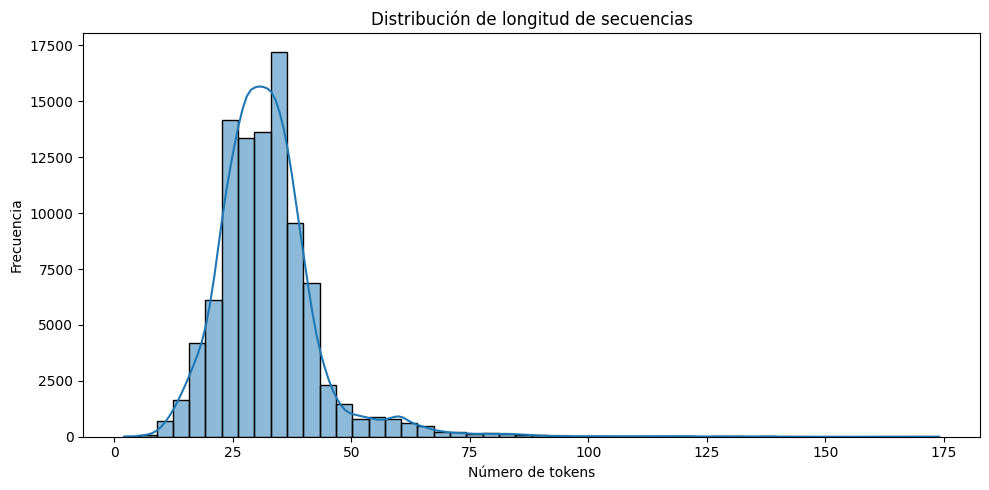

In [73]:
plt.figure(figsize=(10, 5))

sns.histplot(sequence_lengths, bins=50, kde=True)

plt.title("Distribución de longitud de secuencias")
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


In [74]:
pair_monitor = pd.DataFrame({
    "window_size": list(positive_pairs_by_window.keys()),
    "positive_pairs": [
        len(pairs)
        for pairs in positive_pairs_by_window.values()
    ]
})

pair_monitor


,window_size,positive_pairs
0,2,11824596
1,3,17448920
2,4,22881264


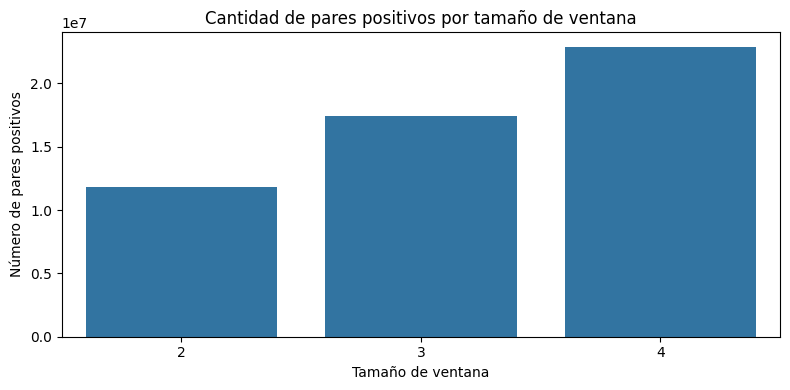

In [75]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=pair_monitor,
    x="window_size",
    y="positive_pairs"
)

plt.title("Cantidad de pares positivos por tamaño de ventana")
plt.xlabel("Tamaño de ventana")
plt.ylabel("Número de pares positivos")
plt.tight_layout()
plt.show()


In [76]:
NEGATIVE_RATIO = 1

pair_monitor["negative_pairs"] = pair_monitor["positive_pairs"] * NEGATIVE_RATIO
pair_monitor["total_training_pairs"] = (
    pair_monitor["positive_pairs"] + pair_monitor["negative_pairs"]
)

pair_monitor


,window_size,positive_pairs,negative_pairs,total_training_pairs
0,2,11824596,11824596,23649192
1,3,17448920,17448920,34897840
2,4,22881264,22881264,45762528


In [77]:
MAX_RECOMMENDED_PAIRS = 10_000_000

for _, row in pair_monitor.iterrows():
    window_size = row["window_size"]
    total_pairs = row["total_training_pairs"]

    if total_pairs > MAX_RECOMMENDED_PAIRS:
        print(
            f"Ventana {window_size}: {total_pairs:,} pares. "
            "Puede ser pesado para memoria o tiempo de entrenamiento."
        )
    else:
        print(
            f"Ventana {window_size}: {total_pairs:,} pares. "
            "Cantidad razonable para continuar."
        )


Ventana 2: 23,649,192 pares. Puede ser pesado para memoria o tiempo de entrenamiento.
Ventana 3: 34,897,840 pares. Puede ser pesado para memoria o tiempo de entrenamiento.
Ventana 4: 45,762,528 pares. Puede ser pesado para memoria o tiempo de entrenamiento.


In [78]:
MAX_POSITIVE_PAIRS = 2_000_000

positive_pairs_sampled_by_window = {}

for window_size, pairs in positive_pairs_by_window.items():
    if len(pairs) > MAX_POSITIVE_PAIRS:
        sampled_indices = np.random.choice(
            len(pairs),
            size=MAX_POSITIVE_PAIRS,
            replace=False
        )

        sampled_pairs = [
            pairs[index]
            for index in sampled_indices
        ]

        positive_pairs_sampled_by_window[window_size] = sampled_pairs

        print(f"Ventana {window_size}: reducido de {len(pairs)} a {len(sampled_pairs)} pares")
    else:
        positive_pairs_sampled_by_window[window_size] = pairs

        print(f"Ventana {window_size}: se mantiene con {len(pairs)} pares")


Ventana 2: reducido de 11824596 a 2000000 pares
Ventana 3: reducido de 17448920 a 2000000 pares
Ventana 4: reducido de 22881264 a 2000000 pares


In [79]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)


# 3. Entrenamiento

In [80]:
histories = {}
models = {}

EPOCHS = 3
BATCH_SIZE = 1024
NEGATIVE_RATIO = 1

for window_size, embedding_dim in EXPERIMENTS:
    print(f"Entrenando modelo ventana={window_size}, embedding={embedding_dim}")

    positive_pairs = positive_pairs_sampled_by_window[window_size]

    center_words, context_words, labels = generate_training_pairs(
        positive_pairs=positive_pairs,
        vocab_size=vocab_size,
        negative_ratio=NEGATIVE_RATIO,
        random_state=42
    )

    model = build_skipgram_model(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim
    )

    history = model.fit(
        x=[center_words, context_words],
        y=labels,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stopping],
        verbose=1
    )

    experiment_name = f"window_{window_size}_embedding_{embedding_dim}"

    models[experiment_name] = model
    histories[experiment_name] = history.history


Entrenando modelo ventana=2, embedding=100
Epoch 1/3
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 112s 31ms/step - accuracy: 0.6640 - loss: 0.6436 - val_accuracy: 0.7025 - val_loss: 0.6209
Epoch 2/3
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 111s 31ms/step - accuracy: 0.7671 - loss: 0.5584 - val_accuracy: 0.7090 - val_loss: 0.6273
Entrenando modelo ventana=2, embedding=200
Epoch 1/3
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 227s 64ms/step - accuracy: 0.6718 - loss: 0.6451 - val_accuracy: 0.7101 - val_loss: 0.6239
Epoch 2/3
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 224s 64ms/step - accuracy: 0.7765 - loss: 0.5596 - val_accuracy: 0.7202 - val_loss: 0.6340
Entrenando modelo ventana=2, embedding=312
Epoch 1/3
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 342s 97ms/step - accuracy: 0.8375 - loss: 0.4070 - val_accuracy: 0.8563 - val_loss: 0.3716
Epoch 2/3
3516/3516 ━━━━━━━━━━━━━━━━━━━━ 338s 96ms/step - accuracy: 0.8817 - loss: 0.3276 - val_accuracy: 0.8669 - val_loss: 0.3718
Entrenando modelo ventana=3, embedding=100
Epoch 1/3
3516/3516 ━━━━━━━━━━━━━━━━

## 3.1 Resultados

### 3.1.1 Graficar pérdida por época

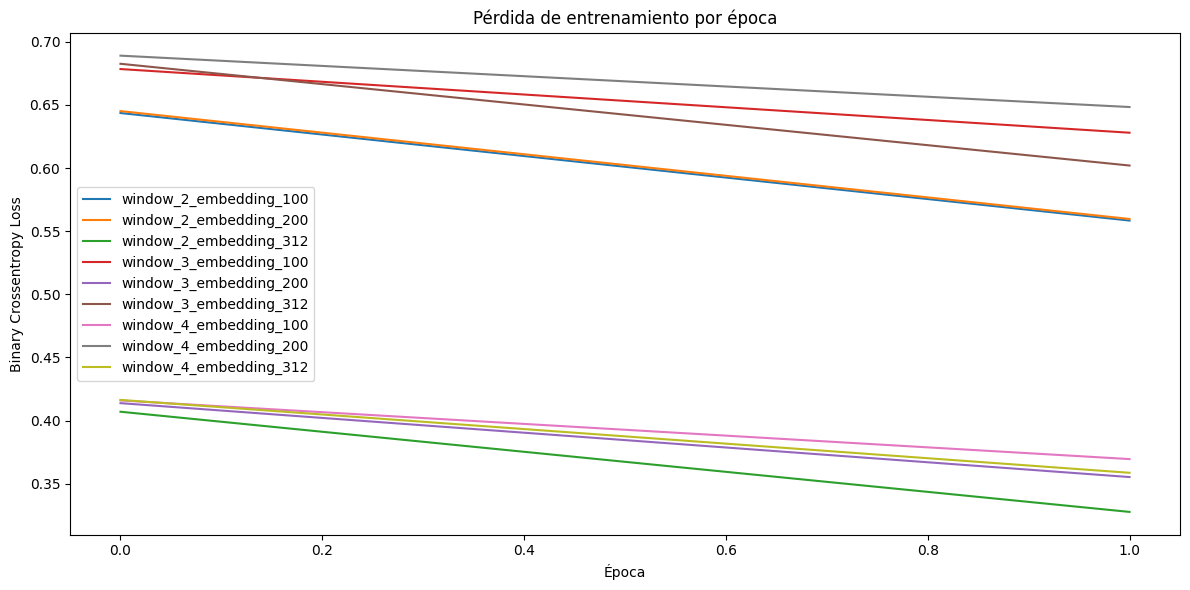

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for experiment_name, history in histories.items():
    plt.plot(
        history["loss"],
        label=experiment_name
    )

plt.title("Pérdida de entrenamiento por época")
plt.xlabel("Época")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.tight_layout()
plt.show()


### 3.1.2 Graficar pérdida de validación

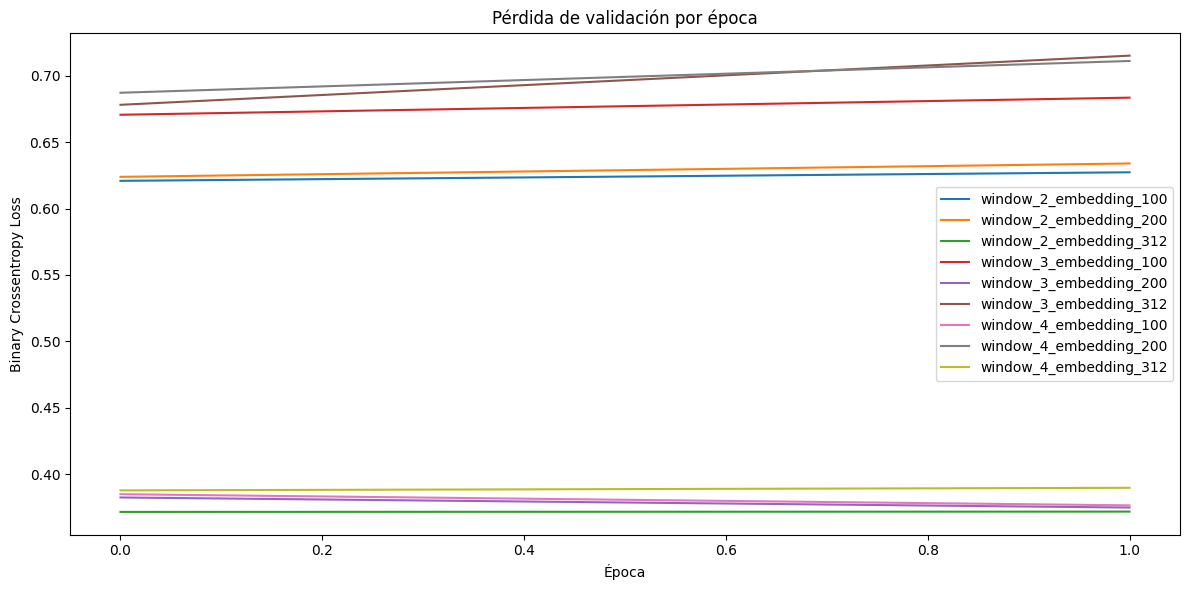

In [82]:
plt.figure(figsize=(12, 6))

for experiment_name, history in histories.items():
    plt.plot(
        history["val_loss"],
        label=experiment_name
    )

plt.title("Pérdida de validación por época")
plt.xlabel("Época")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.tight_layout()
plt.show()


### 3.1.3 Extraer embeddings entrenados

In [83]:
embeddings_by_model = {}

for experiment_name, model in models.items():
    embedding_matrix = model.get_layer("word_embedding").get_weights()[0]
    embeddings_by_model[experiment_name] = embedding_matrix

    print(experiment_name, embedding_matrix.shape)


window_2_embedding_100 (36371, 100)
window_2_embedding_200 (36371, 200)
window_2_embedding_312 (36371, 312)
window_3_embedding_100 (36371, 100)
window_3_embedding_200 (36371, 200)
window_3_embedding_312 (36371, 312)
window_4_embedding_100 (36371, 100)
window_4_embedding_200 (36371, 200)
window_4_embedding_312 (36371, 312)


### 3.1.4 Buscar palabras similares

In [84]:
from sklearn.metrics.pairwise import cosine_similarity

def most_similar_words(word, experiment_name, top_n=10):
    if word not in word_to_index:
        return f"La palabra '{word}' no está en el vocabulario."

    embedding_matrix = embeddings_by_model[experiment_name]

    word_index = word_to_index[word]
    word_vector = embedding_matrix[word_index].reshape(1, -1)

    similarities = cosine_similarity(
        word_vector,
        embedding_matrix
    )[0]

    similar_indices = similarities.argsort()[::-1][1:top_n + 1]

    results = [
        (index_to_word[idx], similarities[idx])
        for idx in similar_indices
        if idx in index_to_word
    ]

    return results

most_similar_words(
    word="market",
    experiment_name=list(models.keys())[0],
    top_n=10
)


[('cents', np.float32(0.53611255)),
 ('distress', np.float32(0.5344683)),
 ('price', np.float32(0.5275921)),
 ('sides', np.float32(0.5117596)),
 ('sport', np.float32(0.49324825)),
 ('solomons', np.float32(0.49041495)),
 ('progress', np.float32(0.48913017)),
 ('sketches', np.float32(0.48720688)),
 ('seats', np.float32(0.48710108)),
 ('store', np.float32(0.48339343))]

### 3.1.5 Matriz de confusión

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

def plot_skipgram_confusion_matrix(
    model,
    center_words,
    context_words,
    labels,
    threshold=0.5,
    title="Matriz de confusión"
):
    y_prob = model.predict(
        [center_words, context_words],
        batch_size=4096,
        verbose=0
    )

    y_pred = (y_prob.ravel() >= threshold).astype(int)

    cm = confusion_matrix(labels, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Par negativo", "Par positivo"]
    )

    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print(classification_report(
        labels,
        y_pred,
        target_names=["Par negativo", "Par positivo"]
    ))

    return cm


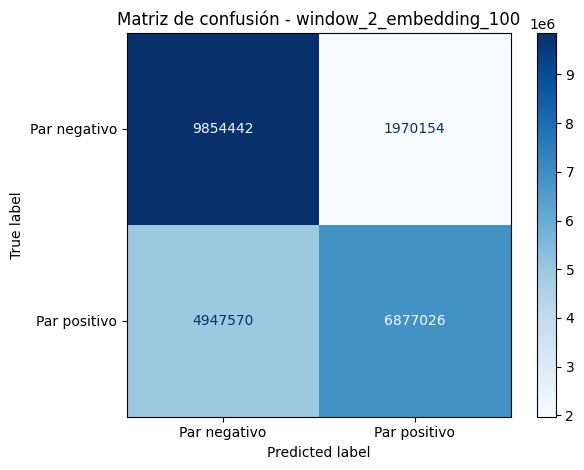

              precision    recall  f1-score   support

Par negativo       0.67      0.83      0.74  11824596
Par positivo       0.78      0.58      0.67  11824596

    accuracy                           0.71  23649192
   macro avg       0.72      0.71      0.70  23649192
weighted avg       0.72      0.71      0.70  23649192



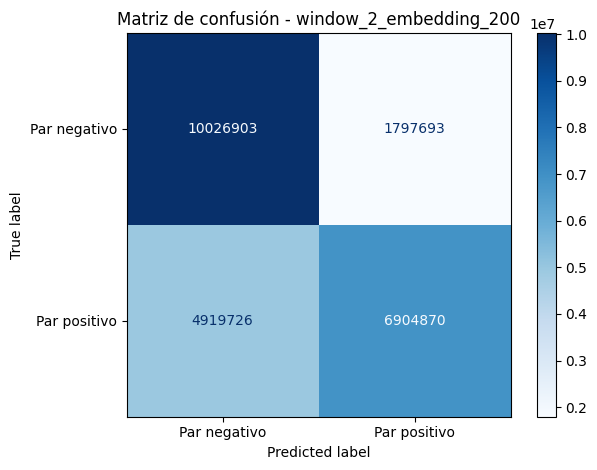

              precision    recall  f1-score   support

Par negativo       0.67      0.85      0.75  11824596
Par positivo       0.79      0.58      0.67  11824596

    accuracy                           0.72  23649192
   macro avg       0.73      0.72      0.71  23649192
weighted avg       0.73      0.72      0.71  23649192



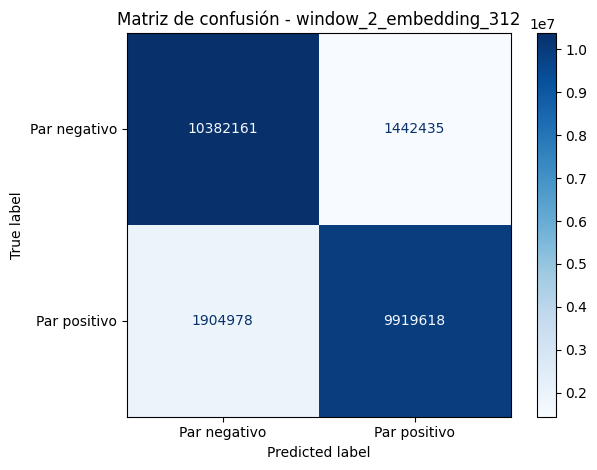

              precision    recall  f1-score   support

Par negativo       0.84      0.88      0.86  11824596
Par positivo       0.87      0.84      0.86  11824596

    accuracy                           0.86  23649192
   macro avg       0.86      0.86      0.86  23649192
weighted avg       0.86      0.86      0.86  23649192



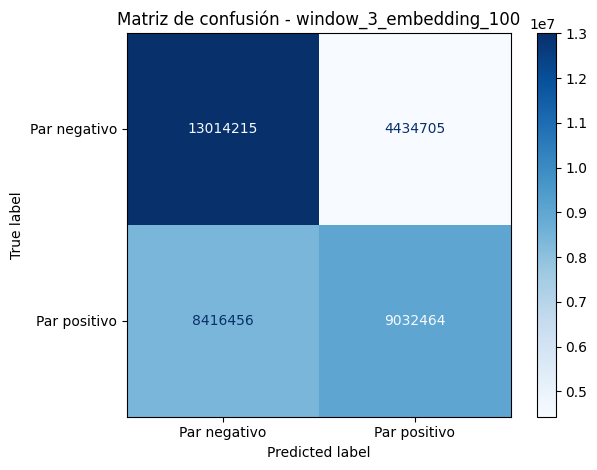

              precision    recall  f1-score   support

Par negativo       0.61      0.75      0.67  17448920
Par positivo       0.67      0.52      0.58  17448920

    accuracy                           0.63  34897840
   macro avg       0.64      0.63      0.63  34897840
weighted avg       0.64      0.63      0.63  34897840



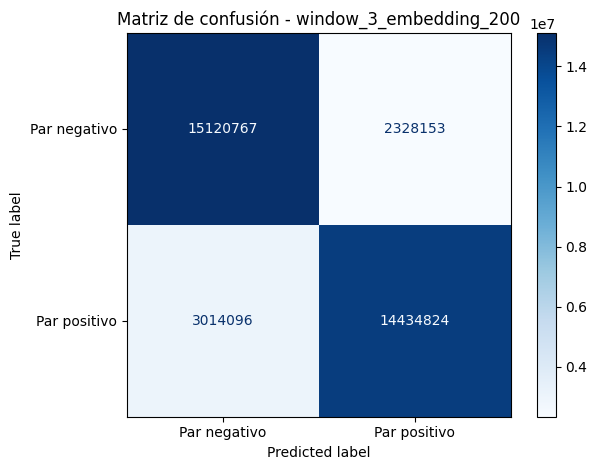

              precision    recall  f1-score   support

Par negativo       0.83      0.87      0.85  17448920
Par positivo       0.86      0.83      0.84  17448920

    accuracy                           0.85  34897840
   macro avg       0.85      0.85      0.85  34897840
weighted avg       0.85      0.85      0.85  34897840



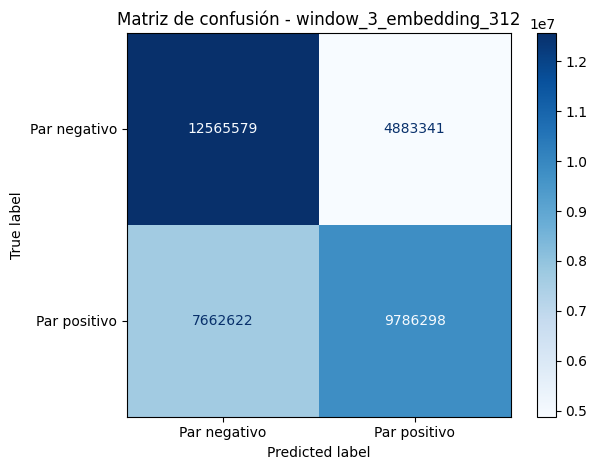

              precision    recall  f1-score   support

Par negativo       0.62      0.72      0.67  17448920
Par positivo       0.67      0.56      0.61  17448920

    accuracy                           0.64  34897840
   macro avg       0.64      0.64      0.64  34897840
weighted avg       0.64      0.64      0.64  34897840



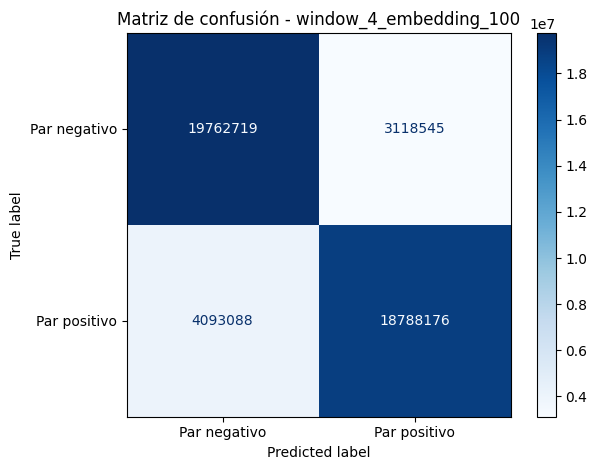

              precision    recall  f1-score   support

Par negativo       0.83      0.86      0.85  22881264
Par positivo       0.86      0.82      0.84  22881264

    accuracy                           0.84  45762528
   macro avg       0.84      0.84      0.84  45762528
weighted avg       0.84      0.84      0.84  45762528



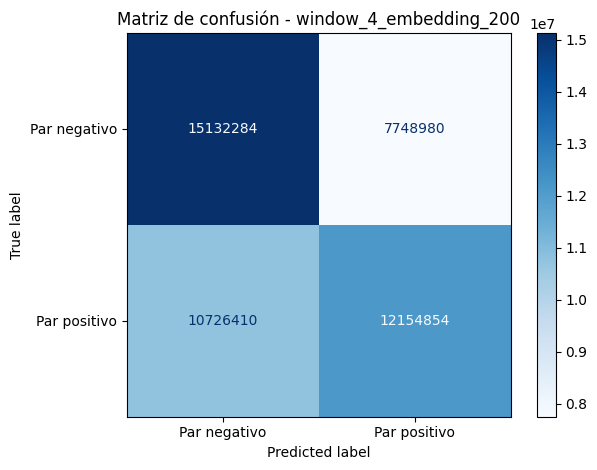

              precision    recall  f1-score   support

Par negativo       0.59      0.66      0.62  22881264
Par positivo       0.61      0.53      0.57  22881264

    accuracy                           0.60  45762528
   macro avg       0.60      0.60      0.59  45762528
weighted avg       0.60      0.60      0.59  45762528



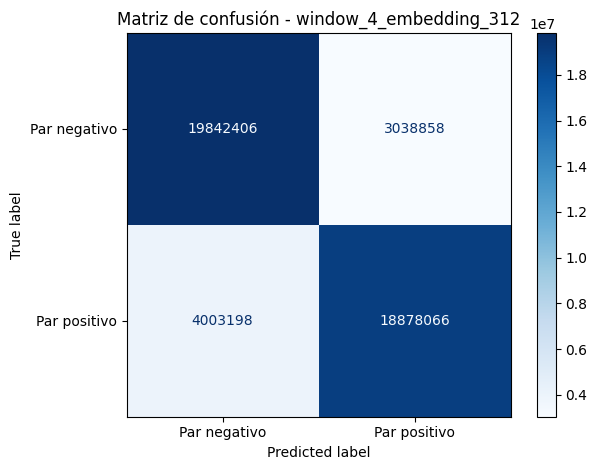

              precision    recall  f1-score   support

Par negativo       0.83      0.87      0.85  22881264
Par positivo       0.86      0.83      0.84  22881264

    accuracy                           0.85  45762528
   macro avg       0.85      0.85      0.85  45762528
weighted avg       0.85      0.85      0.85  45762528



In [86]:
confusion_matrices = {}

for experiment_name, model in models.items():
    parts = experiment_name.split("_")
    window_size = int(parts[1])

    positive_pairs = positive_pairs_by_window[window_size]

    center_words, context_words, labels = generate_training_pairs(
        positive_pairs=positive_pairs,
        vocab_size=vocab_size,
        negative_ratio=NEGATIVE_RATIO,
        random_state=123
    )

    cm = plot_skipgram_confusion_matrix(
        model=model,
        center_words=center_words,
        context_words=context_words,
        labels=labels,
        threshold=0.5,
        title=f"Matriz de confusión - {experiment_name}"
    )

    confusion_matrices[experiment_name] = cm


Los mejores resultados surgen con embedding = 312, especialmente en ventanas 2 y 4, con accuracy y f1 = 0.85–0.86.
Ventana 3 muestra más inestabilidad: el embedding 200 rinde muy bien (0.85), pero 100 y 312 bajan mucho.
Ventana 4 es más estable, con coherencia entre embedding 100 y 312.
Embedding 200 parece inconsistente: mejora en ventana 3, pero empeora en ventana 4.

### 3.1.5 Riesgo de overfitting

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def check_overfitting(
    histories,
    min_gap=0.05,
    relative_gap=0.15
):
    results = []

    for experiment_name, history in histories.items():
        train_loss = np.array(history["loss"])
        val_loss = np.array(history["val_loss"])

        best_val_epoch = int(np.argmin(val_loss)) + 1
        final_epoch = len(train_loss)

        final_train_loss = train_loss[-1]
        final_val_loss = val_loss[-1]
        best_val_loss = val_loss.min()

        absolute_gap = final_val_loss - final_train_loss
        relative_gap_value = absolute_gap / max(final_train_loss, 1e-8)

        train_loss_change = train_loss[0] - train_loss[-1]
        val_loss_change_after_best = final_val_loss - best_val_loss

        possible_overfitting = (
            absolute_gap > min_gap
            and relative_gap_value > relative_gap
            and val_loss_change_after_best > 0
        )

        results.append({
            "model": experiment_name,
            "epochs_trained": final_epoch,
            "best_val_epoch": best_val_epoch,
            "initial_train_loss": train_loss[0],
            "final_train_loss": final_train_loss,
            "best_val_loss": best_val_loss,
            "final_val_loss": final_val_loss,
            "absolute_gap": absolute_gap,
            "relative_gap": relative_gap_value,
            "train_loss_reduction": train_loss_change,
            "val_loss_increase_after_best": val_loss_change_after_best,
            "possible_overfitting": possible_overfitting
        })

    return pd.DataFrame(results).sort_values(
        by=["possible_overfitting", "absolute_gap"],
        ascending=[False, False]
    )

overfitting_report = check_overfitting(histories)

overfitting_report


,model,epochs_trained,best_val_epoch,initial_train_loss,final_train_loss,best_val_loss,final_val_loss,absolute_gap,relative_gap,train_loss_reduction,val_loss_increase_after_best,possible_overfitting
5,window_3_embedding_312,2,1,0.682576,0.601988,0.678167,0.715185,0.113197,0.188039,0.080588,0.037019,True
1,window_2_embedding_200,2,1,0.645103,0.559648,0.623919,0.633986,0.074338,0.132829,0.085455,0.010067,False
0,window_2_embedding_100,2,1,0.643582,0.558406,0.620900,0.627338,0.068932,0.123444,0.085175,0.006438,False
7,window_4_embedding_200,2,1,0.689021,0.648321,0.687243,0.711168,0.062846,0.096937,0.040699,0.023925,False
3,window_3_embedding_100,2,1,0.678405,0.627971,0.670672,0.683548,0.055577,0.088503,0.050434,0.012875,False
2,window_2_embedding_312,2,1,0.406984,0.327636,0.371591,0.371828,0.044192,0.134880,0.079348,0.000237,False
8,window_4_embedding_312,2,1,0.416344,0.358615,0.387800,0.389742,0.031127,0.086798,0.057730,0.001942,False
4,window_3_embedding_200,2,2,0.413781,0.355245,0.374873,0.374873,0.019628,0.055253,0.058536,0.000000,False
6,window_4_embedding_100,2,2,0.415914,0.369484,0.376526,0.376526,0.007042,0.019060,0.046430,0.000000,False
